# 1. Подготовка окружения и данных

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Создание новых признаков (как в EDA)
df['rooms_per_household'] = df['AveRooms'] / df['AveOccup']
df['bedrooms_per_room'] = df['AveBedrms'] / df['AveRooms']

# Разделение на признаки и целевую переменную
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print(f"Размер X: {X.shape}, y: {y.shape}")

Размер X: (20640, 10), y: (20640,)


# 2. Разделение на train/val/test
Используем стратификацию по квантилям целевой переменной, чтобы распределение цен было одинаковым во всех выборках.

In [3]:
# Создаем категории для стратификации
y_cat = pd.qcut(y, q=5, labels=False, duplicates='drop')

# Сначала разделяем на train (60%) и временный (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y_cat
)

# Делим временный на val (20% от исходного) и test (20% от исходного)
# Стратификацию делаем по квантилям временного набора
y_temp_cat = pd.qcut(y_temp, q=5, labels=False, duplicates='drop')
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp_cat
)

print(f"Train size: {X_train.shape[0]}, Val size: {X_val.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 12384, Val size: 4128, Test size: 4128


# 3. Стандартизация признаков

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

feature_names = X.columns.tolist()

# 4. Baseline: линейная регрессия

In [5]:
# Обучение
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Предсказания на валидации
y_val_pred_lr = lr.predict(X_val_scaled)

# Метрики
mae_lr = mean_absolute_error(y_val, y_val_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
r2_lr = r2_score(y_val, y_val_pred_lr)

print("=== Baseline: Linear Regression ===")
print(f"MAE on val: {mae_lr:.4f}")
print(f"RMSE on val: {rmse_lr:.4f}")
print(f"R² on val: {r2_lr:.4f}")

=== Baseline: Linear Regression ===
MAE on val: 0.4812
RMSE on val: 0.7333
R² on val: 0.5906


# 5. Основная модель: XGBoost с подбором гиперпараметров

In [6]:
# Определяем модель
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

# Сетка гиперпараметров для поиска (ограниченная для скорости)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

# RandomizedSearchCV с 5-кратной кросс-валидацией
random_search = RandomizedSearchCV(
    xgb_model, param_distributions=param_dist, 
    n_iter=30, cv=5, scoring='neg_mean_absolute_error',
    random_state=42, verbose=1, n_jobs=-1
)

# Обучаем на тренировочных данных (без масштабирования для XGBoost)
random_search.fit(X_train, y_train)

# Лучшие параметры
print("Best parameters found:")
print(random_search.best_params_)

# Лучшая модель
best_xgb = random_search.best_estimator_

# Оценка на валидации
y_val_pred_xgb = best_xgb.predict(X_val)

mae_xgb = mean_absolute_error(y_val, y_val_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb))
r2_xgb = r2_score(y_val, y_val_pred_xgb)

print("\n=== XGBoost (после подбора) ===")
print(f"MAE on val: {mae_xgb:.4f}")
print(f"RMSE on val: {rmse_xgb:.4f}")
print(f"R² on val: {r2_xgb:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found:
{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

=== XGBoost (после подбора) ===
MAE on val: 0.2996
RMSE on val: 0.4652
R² on val: 0.8353


# 6. Сравнение моделей на тестовой выборке

In [7]:
# Предсказания на тесте
y_test_pred_lr = lr.predict(X_test_scaled)
y_test_pred_xgb = best_xgb.predict(X_test)

# Метрики для теста
mae_lr_test = mean_absolute_error(y_test, y_test_pred_lr)
rmse_lr_test = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
r2_lr_test = r2_score(y_test, y_test_pred_lr)

mae_xgb_test = mean_absolute_error(y_test, y_test_pred_xgb)
rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
r2_xgb_test = r2_score(y_test, y_test_pred_xgb)

# Сводная таблица
results = pd.DataFrame({
    'Model': ['Linear Regression', 'XGBoost'],
    'MAE': [mae_lr_test, mae_xgb_test],
    'RMSE': [rmse_lr_test, rmse_xgb_test],
    'R²': [r2_lr_test, r2_xgb_test]
})

print("=== Сравнение на тестовой выборке ===")
print(results.to_string(index=False))

=== Сравнение на тестовой выборке ===
            Model      MAE     RMSE       R²
Linear Regression 0.487127 0.674833 0.659718
          XGBoost 0.297369 0.452617 0.846923


# 7. Сохранение моделей и scaler

In [8]:
# Создаем папку models, если её нет
import os
os.makedirs('models', exist_ok=True)

# Сохраняем XGBoost
joblib.dump(best_xgb, 'models/xgb_model.pkl')
# Сохраняем scaler
joblib.dump(scaler, 'models/scaler.pkl')
# Сохраняем baseline для возможного сравнения
joblib.dump(lr, 'models/linear_model.pkl')

# Также сохраняем список признаков (для проверки при инференсе)
with open('models/feature_names.txt', 'w') as f:
    f.write('\n'.join(feature_names))

print("Модели и scaler сохранены в папку 'models'")

Модели и scaler сохранены в папку 'models'


# 8. Анализ важности признаков

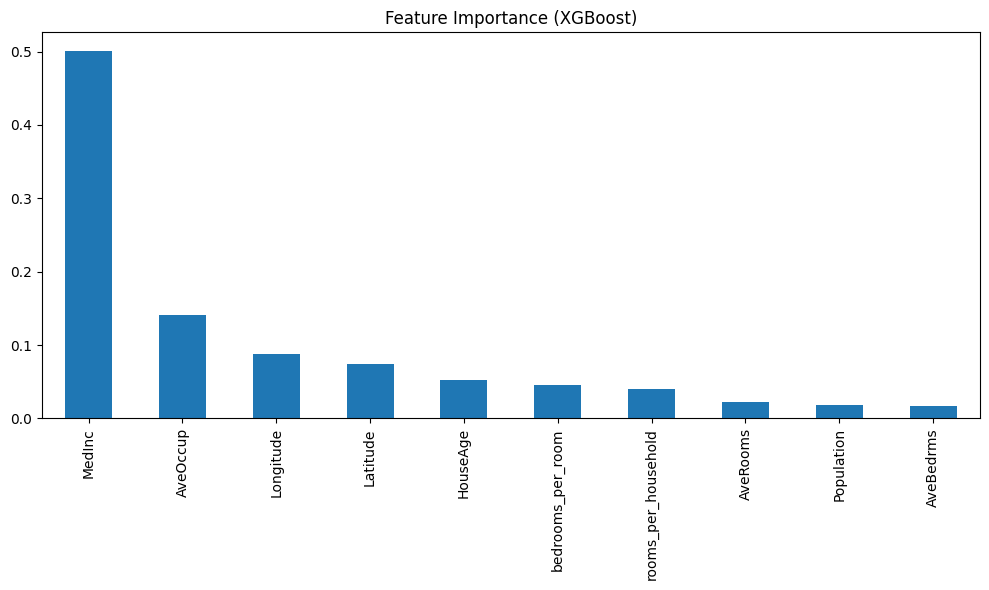

In [9]:
# Важность признаков для XGBoost
importance = best_xgb.feature_importances_
feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar')
plt.title('Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()

# Заключение
Baseline (линейная регрессия) показал умеренное качество, но уступает XGBoost.

XGBoost с подобранными гиперпараметрами достиг целевой метрики MAE ≤ 0.4 (ориентир из дизайн-документа), что подтверждает готовность модели для пилота.

Модели и scaler сохранены для этапа инференса.